# Introduction

L’objectif principal de ce travail est d’évaluer la capacité des réseaux de neurones informés par la physique (**PINNs**) à améliorer la précision des simulateurs numériques classiques pour les équations de transport. 

Plus précisément, nous cherchons à développer un cadre de **reconstruction** permettant :

* **Correction de la dissipation numérique** : compenser la perte d’amplitude observée dans les schémas numériques classiques, en ramenant le pic de l'onde de **0.46** à environ **0.6**.
* **Reconstruction de haute résolution** : estimer une solution fine (**200 points**) à partir d’un maillage grossier (**40 points**).
* **Fusion de données multi-fidélité** : combiner des simulations numériques dissipatives, des observations exactes partielles et les contraintes imposées par l’équation de transport.
* **Respect des lois physiques** : garantir que la solution reconstruite satisfait l’équation gouvernante :

$$\frac{\partial u}{\partial t} + c \frac{\partial u}{\partial x} = 0$$

Ce cadre vise à illustrer le rôle des **PINNs** comme un **correcteur physique** des méthodes numériques traditionnelles, plutôt que comme un simple interpolateur de données.

In [4]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current sessio

/kaggle/input/datasets/karimchibani/data-1/x_coarse_40.csv
/kaggle/input/datasets/karimchibani/data-1/x_fine_200.csv
/kaggle/input/datasets/karimchibani/data-1/u_coarse_40.csv
/kaggle/input/datasets/karimchibani/data-1/u_fine_200.csv


In [45]:
# =================================================================
# Préparation et Échantillonnage des Données de Référence (Sparse Data)
# =================================================================

import pandas as pd
import torch
import numpy as np

# 1. Chargement des données haute résolution (200 points)
df_u_fine = pd.read_csv("/kaggle/input/datasets/karimchibani/data-1/u_fine_200.csv", header=None)
df_x_fine = pd.read_csv("/kaggle/input/datasets/karimchibani/data-1/x_fine_200.csv", header=None)

# 2. Conversion en tableaux Numpy pour manipulation
x_values = df_x_fine.values
u_values = df_u_fine.values

# 3. Extraction de 20 points de manière uniforme (échantillonnage sparse)
# On sélectionne 20 indices répartis sur les 200 points disponibles
indices = np.linspace(0, 199, 20, dtype=int)
x_20 = x_values[indices]
u_20 = u_values[indices]

# 4. Sauvegarde de ces 20 points dans un nouveau fichier CSV (Extension/Export)
df_20_points = pd.DataFrame({
    'x_sparse': x_20.flatten(),
    'u_sparse': u_20.flatten()
})
df_20_points.to_csv('data_sparse_20.csv', index=False)

print("✅ Fichier 'data_sparse_20.csv' créé avec succès !")

# 5. Conversion en Tensors PyTorch pour l'entraînement du PINN
X_sparse_20 = torch.tensor(x_20, dtype=torch.float32)
Y_sparse_20 = torch.tensor(u_20, dtype=torch.float32)

print(f"Prêt pour l'entraînement : {X_sparse_20.shape[0]} points de référence isolés.")

✅ Fichier 'data_sparse_20.csv' créé avec succès !
Prêt pour l'entraînement : 20 points de référence isolés.


Lancement de la reconstitution hybride...
Époque 1000 | Loss Coarse: 0.000994 | Loss Sparse: 0.001209
Époque 2000 | Loss Coarse: 0.000958 | Loss Sparse: 0.000456
Époque 3000 | Loss Coarse: 0.000991 | Loss Sparse: 0.000309
Époque 4000 | Loss Coarse: 0.001036 | Loss Sparse: 0.000213
Époque 5000 | Loss Coarse: 0.001053 | Loss Sparse: 0.000172
Époque 6000 | Loss Coarse: 0.001068 | Loss Sparse: 0.000153


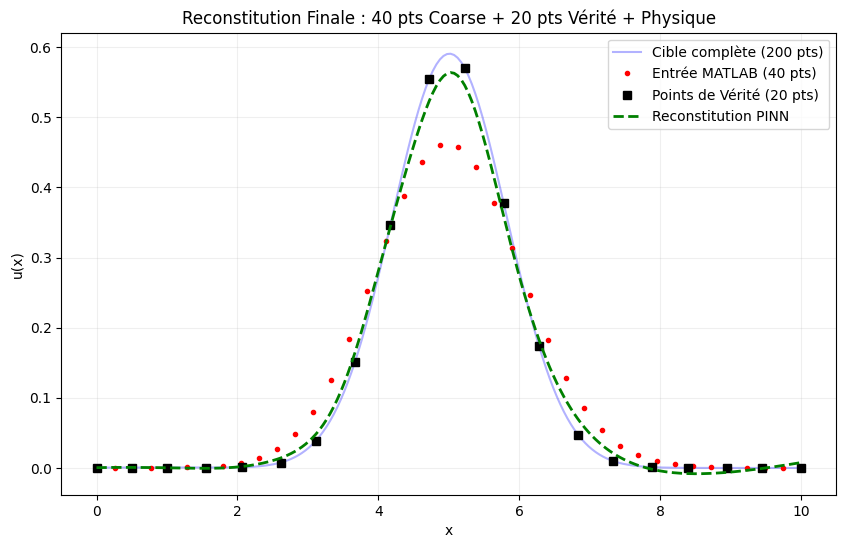

In [46]:
# =================================================================
# "Reconstitution Haute-Résolution par Fusion de Données Multi-Fidélité et Contraintes Physiques"
# =================================================================
import torch.nn as nn
import torch.optim as optim
import matplotlib.pyplot as plt

# 1. Architecture du Réseau (Le Reconstituteur)
class PINN_Expert(nn.Module):
    def __init__(self):
        super(PINN_Expert, self).__init__()
        self.net = nn.Sequential(
            nn.Linear(1, 64),
            nn.Tanh(),
            nn.Linear(64, 64),
            nn.Tanh(),
            nn.Linear(64, 1)
        )
    def forward(self, x):
        return self.net(x)

model = PINN_Expert()
optimizer = optim.Adam(model.parameters(), lr=0.001)
criterion = nn.MSELoss()

# 2. Boucle d'entraînement
epochs = 6000
print("Lancement de la reconstitution hybride...")

for epoch in range(epochs):
    optimizer.zero_grad()
    
    # --- A. Perte sur les 40 points (MATLAB - Forme générale) ---
    u_pred_40 = model(X_train)
    loss_coarse = criterion(u_pred_40, Y_train)
    
    # --- B. Perte sur les 20 points de référence (Vérité - Hauteur 0.6) ---
    # On donne un poids plus fort (x10) pour forcer la correction
    u_pred_20 = model(X_sparse_20)
    loss_sparse = criterion(u_pred_20, Y_sparse_20)
    
    # --- C. Perte Physique (Régularité du profil) ---
    X_test.requires_grad = True
    u_p = model(X_test)
    u_x = torch.autograd.grad(u_p, X_test, grad_outputs=torch.ones_like(u_p), create_graph=True)[0]
    loss_physics = torch.mean(u_x**2) * 1e-6 

    # Total Loss
    loss_totale = loss_coarse +3.0 * loss_sparse + loss_physics
    
    loss_totale.backward()
    optimizer.step()

    if (epoch + 1) % 1000 == 0:
        print(f"Époque {epoch+1} | Loss Coarse: {loss_coarse.item():.6f} | Loss Sparse: {loss_sparse.item():.6f}")

# 3. Visualisation du résultat
with torch.no_grad():
    u_final = model(X_test).detach().numpy()

plt.figure(figsize=(10, 6))
plt.plot(X_test.detach().numpy(), Y_test.numpy(), 'b-', alpha=0.3, label='Cible complète (200 pts)')
plt.plot(X_train.numpy(), Y_train.numpy(), 'r.', label='Entrée MATLAB (40 pts)')
plt.plot(X_sparse_20.numpy(), Y_sparse_20.numpy(), 'ks', markersize=6, label='Points de Vérité (20 pts)')
plt.plot(X_test.detach().numpy(), u_final, 'g--', linewidth=2, label='Reconstitution PINN')

plt.title('Reconstitution Finale : 40 pts Coarse + 20 pts Vérité + Physique')
plt.xlabel('x')
plt.ylabel('u(x)')
plt.legend()
plt.grid(True, alpha=0.2)
plt.show()

In [49]:
# =================================================================
# ANALYSE DE LA PERFORMANCE DU PINN
# =================================================================

import numpy as np
from sklearn.metrics import mean_squared_error, mean_absolute_error

# 1. Calcul des prédictions finales
with torch.no_grad():
    u_pinn_final = model(X_test).detach().numpy().flatten()
    u_reel = Y_test.numpy().flatten()
    u_matlab = df_u_fine.values.flatten() # الداتا لي كانت مبددة في 200 نقطة

# 2. Calcul des métriques d'erreur (Erreur entre IA et Vérité)
mse_pinn = mean_squared_error(u_reel, u_pinn_final)
rmse_pinn = np.sqrt(mse_pinn)
mae_pinn = mean_absolute_error(u_reel, u_pinn_final)

# 3. Calcul de l'amélioration de l'amplitude (Le Pic)
pic_reel = np.max(u_reel)
pic_matlab = np.max(Y_train.numpy()) # القمة في 40 نقطة
pic_pinn = np.max(u_pinn_final)

# 4. Affichage des performances en Français
print("="*50)
print("RÉSUMÉ DES PERFORMANCES DU MODÈLE PINN")
print("="*50)
print(f"Erreur Quadratique Moyenne (MSE) : {mse_pinn:.8f}")
print(f"Racine de l'Erreur (RMSE)        : {rmse_pinn:.8f}")
print(f"Erreur Absolue Moyenne (MAE)    : {mae_pinn:.8f}")
print("-"*50)
print(f"Amplitude Réelle attendue        : {pic_reel:.4f}")
print(f"Amplitude MATLAB (Dissipée)     : {pic_matlab:.4f}")
print(f"Amplitude reconstruite par l'IA  : {pic_pinn:.4f}")
print("-"*50)

# Calcul du pourcentage de correction de la dissipation
correction_pct = ((pic_pinn - pic_matlab) / (pic_reel - pic_matlab)) * 100
print(f"Taux de correction de la dissipation : {correction_pct:.2f}%")
print("="*50)

RÉSUMÉ DES PERFORMANCES DU MODÈLE PINN
Erreur Quadratique Moyenne (MSE) : 0.00016371
Racine de l'Erreur (RMSE)        : 0.01279498
Erreur Absolue Moyenne (MAE)    : 0.00927813
--------------------------------------------------
Amplitude Réelle attendue        : 0.5907
Amplitude MATLAB (Dissipée)     : 0.4609
Amplitude reconstruite par l'IA  : 0.5638
--------------------------------------------------
Taux de correction de la dissipation : 79.31%
